<a href="https://colab.research.google.com/github/AbelPhilippe/LA_Crimes/blob/main/LA_CrimeData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATASET

# The dataset file provides a structured record of crime incidents reported in the United States from 2020 to the present. It typically includes detailed columns representing:

# Incident Details: Unique incident identifiers, crime types (e.g., violent crime, property crime, drug offenses), and descriptive classifications.
# Geographical Information: State, city, and precise location data where the incidents occurred, allowing for spatial analysis of crime distribution.
# Temporal Data: Dates and times of reported incidents, enabling the examination of temporal crime trends.
# Demographics: Information on victims and offenders, such as age, gender, and race (if available and anonymized).
# Law Enforcement Actions: Arrest details, case statuses, and jurisdictional information.
# Additional Attributes: Method of crime reporting (UCR/NIBRS), relationship between victims and offenders, and weapon usage (if applicable).
# The file format (likely CSV) is designed for easy integration with data analysis tools, supporting research in crime trend forecasting, policy formulation, and public safety optimization.

In [1]:
!pip install streamlit --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 82.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 8.4 MB/s eta 0:00:00


In [8]:
import os
import pandas as pd
import sklearn.model_selection
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import streamlit as st
import warnings
import folium

from folium.plugins import HeatMap
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('/content/LA Crime Data 2020 to Present.csv')
df

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,03/01/2020 12:00:00 AM,03/01/2020 12:00:00 AM,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,02/09/2020 12:00:00 AM,02/08/2020 12:00:00 AM,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,...,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,200320258,11/11/2020 12:00:00 AM,11/04/2020 12:00:00 AM,1700,3,Southwest,356,1,480,BIKE - STOLEN,...,IC,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
3,200907217,05/10/2023 12:00:00 AM,03/10/2020 12:00:00 AM,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),...,IC,Invest Cont,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,200412582,09/09/2020 12:00:00 AM,09/09/2020 12:00:00 AM,630,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,200 E AVENUE 28,NaN,34.0820,-118.2130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138473,201712564,08/25/2020 12:00:00 AM,08/25/2020 12:00:00 AM,2100,17,Devonshire,1709,2,901,VIOLATION OF RESTRAINING ORDER,...,IC,Invest Cont,901.0,NaN,NaN,NaN,15500 RINALDI ST,NaN,34.2818,-118.4728
138474,201804969,01/17/2020 12:00:00 AM,01/17/2020 12:00:00 AM,1500,18,Southeast,1844,2,626,INTIMATE PARTNER - SIMPLE ASSAULT,...,IC,Invest Cont,626.0,NaN,NaN,NaN,400 E 109TH ST,NaN,33.9374,-118.2681
138475,210504027,12/31/2020 12:00:00 AM,12/31/2020 12:00:00 AM,2355,5,Harbor,504,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,NaN,NaN,NaN,TORRANCE,DENKER,33.8416,-118.3040
138476,201613812,10/08/2020 12:00:00 AM,10/02/2020 12:00:00 AM,1426,16,Foothill,1641,1,440,THEFT PLAIN - PETTY ($950 & UNDER),...,IC,Invest Cont,440.0,NaN,NaN,NaN,AMBOY,PIERCE,34.2570,-118.4273


In [5]:
df.head(10)

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,03/01/2020 12:00:00 AM,03/01/2020 12:00:00 AM,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,02/09/2020 12:00:00 AM,02/08/2020 12:00:00 AM,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,...,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,200320258,11/11/2020 12:00:00 AM,11/04/2020 12:00:00 AM,1700,3,Southwest,356,1,480,BIKE - STOLEN,...,IC,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
3,200907217,05/10/2023 12:00:00 AM,03/10/2020 12:00:00 AM,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),...,IC,Invest Cont,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,200412582,09/09/2020 12:00:00 AM,09/09/2020 12:00:00 AM,630,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,200 E AVENUE 28,NaN,34.0820,-118.2130
5,200209713,05/03/2020 12:00:00 AM,05/02/2020 12:00:00 AM,1800,2,Rampart,245,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,2500 W 4TH ST,NaN,34.0642,-118.2771
6,200200759,07/07/2020 12:00:00 AM,07/07/2020 12:00:00 AM,1340,2,Rampart,265,1,648,ARSON,...,IC,Invest Cont,648.0,998.0,NaN,NaN,JAMES M WOOD,ALVARADO,34.0536,-118.2788
7,201308739,03/27/2020 12:00:00 AM,03/27/2020 12:00:00 AM,1210,13,Newton,1333,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,3200 S SAN PEDRO ST,NaN,34.0170,-118.2643
8,201112065,07/31/2020 12:00:00 AM,07/30/2020 12:00:00 AM,2030,11,Northeast,1161,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,NaN,NaN,NaN,KENMORE ST,FOUNTAIN,34.0953,-118.2974
9,200121929,12/04/2020 12:00:00 AM,12/03/2020 12:00:00 AM,2300,1,Central,105,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,400 SOLANO AV,NaN,34.0710,-118.2302


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138478 entries, 0 to 138477
Data columns (total 28 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DR_NO           138478 non-null  int64  
 1   Date Rptd       138478 non-null  object 
 2   DATE OCC        138478 non-null  object 
 3   TIME OCC        138478 non-null  int64  
 4   AREA            138478 non-null  int64  
 5   AREA NAME       138478 non-null  object 
 6   Rpt Dist No     138478 non-null  int64  
 7   Part 1-2        138478 non-null  int64  
 8   Crm Cd          138478 non-null  int64  
 9   Crm Cd Desc     138478 non-null  object 
 10  Mocodes         120623 non-null  object 
 11  Vict Age        138477 non-null  float64
 12  Vict Sex        121322 non-null  object 
 13  Vict Descent    121319 non-null  object 
 14  Premis Cd       138476 non-null  float64
 15  Premis Desc     138431 non-null  object 
 16  Weapon Used Cd  51910 non-null   float64
 17  Weapon Des

In [12]:
lat, lng = df.LON[0], df.LAT[0]
lat, lng

(np.float64(-118.3506), np.float64(34.0375))

In [9]:
sample_df = df.sample(int(0.1 * len(df)))
lat_lng_pairs = list(zip(list(sample_df.LAT), list(sample_df.LON)))
map = folium.Map()
HeatMap(lat_lng_pairs).add_to(map)
map

In [22]:
top_locations = df['AREA NAME'].value_counts().nlargest(10).index  # Get the top 10 locations

# Create the histogram with only the top locations
graph = px.histogram(df[df['AREA NAME'].isin(top_locations)], x="AREA NAME", title="Top 10 Areas with Highest Crime Indices")
graph.show()
top_locations

Index(['77th Street', 'Central', 'Southwest', 'Hollywood', 'West LA',
       'Wilshire', 'Rampart', 'Harbor', 'Van Nuys', 'Northeast'],
      dtype='object', name='AREA NAME')

In [23]:
top_crimes = df['Crm Cd Desc'].value_counts().nlargest(10)
print(top_crimes)

Crm Cd Desc
VEHICLE - STOLEN                                           14144
BATTERY - SIMPLE ASSAULT                                   11754
VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)     9273
BURGLARY FROM VEHICLE                                       9057
BURGLARY                                                    8815
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT              8267
THEFT PLAIN - PETTY ($950 & UNDER)                          7582
INTIMATE PARTNER - SIMPLE ASSAULT                           7465
THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)             6440
THEFT OF IDENTITY                                           5135
Name: count, dtype: int64


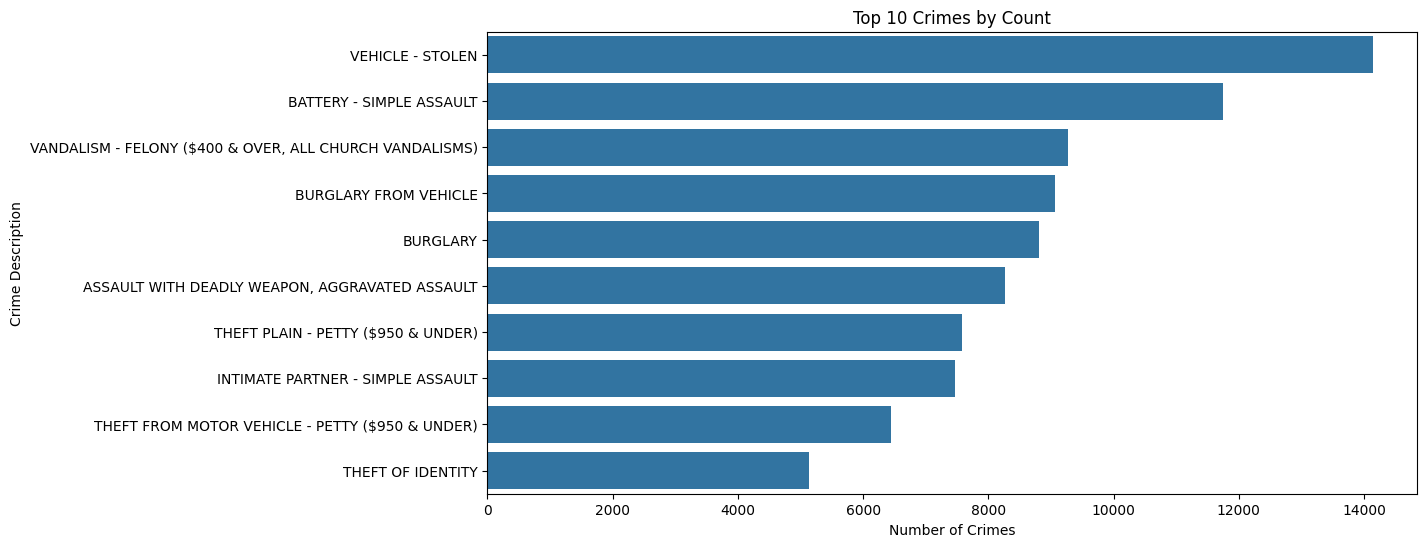

In [24]:
plt.figure(figsize=(12,6))
sns.countplot(y='Crm Cd Desc', data=df, order=df['Crm Cd Desc'].value_counts().iloc[:10].index)
plt.title('Top 10 Crimes by Count')
plt.xlabel('Number of Crimes')
plt.ylabel('Crime Description')
plt.show()

In [31]:
fig = px.pie(top_crimes, values=top_crimes.values,
             names=top_crimes.index, title='Top 10 Crimes',
             color_discrete_sequence=['aliceblue',  'aqua', 'aquamarine', 'darkturquoise'])
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()